In [1]:
import os
import rasterio
import yaml

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.ticker import FuncFormatter, MaxNLocator
from pathlib import Path

In [2]:
os.chdir("..")

In [3]:
with open("config.yaml") as f:
    config = yaml.safe_load(f)

In [4]:
indices_data = Path(config["indices_path"]) / "indices_multiband.tif"

In [5]:
with rasterio.open(indices_data) as src:
    indices_idxs = {src.descriptions[i]: i + 1 for i in range(len(src.descriptions)) }
    
    ndvi = src.read(indices_idxs["ndvi"])
    evi = src.read(indices_idxs["evi"])
    savi = src.read(indices_idxs["savi"])
    ndre = src.read(indices_idxs["ndre"])
    gndvi = src.read(indices_idxs["gndvi"])

## Histograms

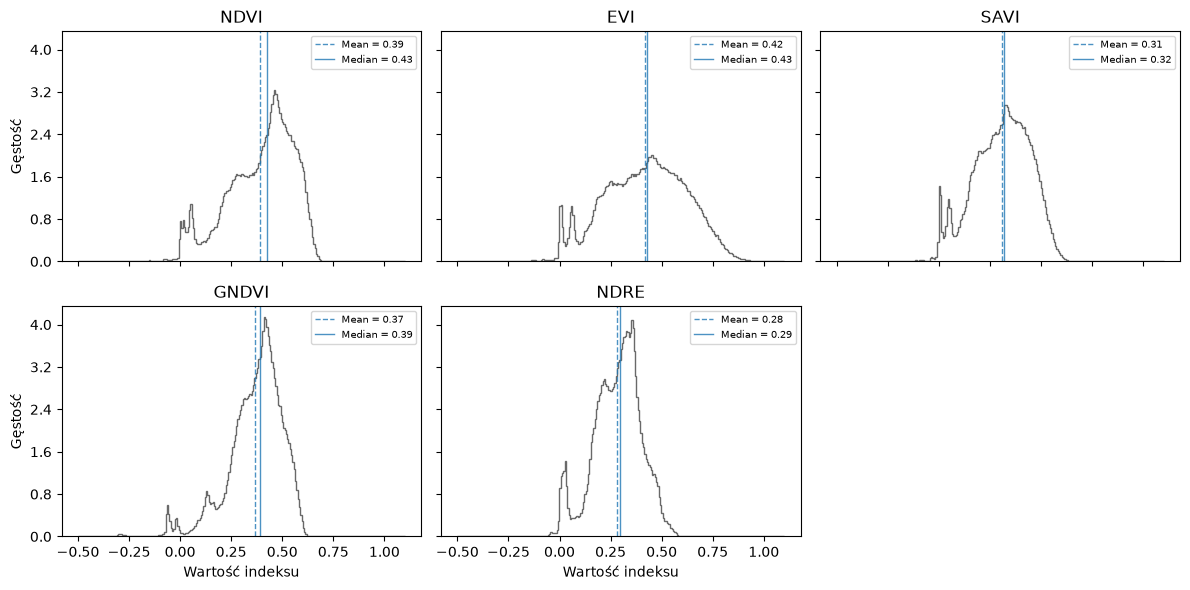

In [6]:
# create a histogram for each index
indices = np.stack([ndvi, evi, savi, gndvi, ndre])
subplot_titles = ["NDVI", "EVI", "SAVI", "GNDVI", "NDRE"]

min_threshold = -0.5
max_threshold = 1.1
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6), sharex=True, sharey=True)

for r in range(rows):
    for c in range(cols):
        index = r * cols + c
        ax = axes[r, c]

        if index < len(indices):
            data = indices[index][np.isfinite(indices[index])]
            mean = np.mean(data[np.isfinite(data)])
            median = np.median(data[np.isfinite(data)])
            
            ax.hist(data, bins=250, density=True, range=(min_threshold, max_threshold), histtype="step", color="dimgray")
            ax.axvline(mean, linestyle="--", linewidth=1, label=f"Mean = {mean:.2f}", alpha=0.8);
            ax.axvline(median, linestyle="-", linewidth=1, label=f"Median = {median:.2f}", alpha=0.8);
            
            ax.set_title(subplot_titles[index])
            ax.legend(fontsize="x-small")
        else:
            ax.axis("off")
        if r == rows - 1:
            ax.set_xlabel("Wartość indeksu")
        if c == 0:
            ax.set_ylabel("Gęstość")
            ax.yaxis.set_major_locator(MaxNLocator(nbins=7))

plt.tight_layout()